## Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.metrics import mae, rmse

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_dataset
from src.models import (
    chronological_train_test_split,
    get_split_information,
    run_chronos2_experiment,
    run_chronos2_historical_forecasts,
)

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Configuration

In [2]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "LD2011_2014.txt"
)

SERIES_ID = "MT_001"

INPUT_CHUNK_LENGTH = 512

HORIZON_24H = 96
HORIZON_48H = 192
HORIZON_7D = 672

## Load Data

In [3]:
df = load_dataset(
    str(DATA_PATH)
)

series_df = (
    df[
        df["series_id"] == SERIES_ID
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print(
    f"Series: {SERIES_ID}"
)

print(
    f"Observations: "
    f"{len(series_df):,}"
)

display(
    series_df.head()
)

Loading dataset: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt


c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\src\data.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Raw shape: (140256, 371)
Series: MT_001
Observations: 140,256


,timestamp,series_id,value
0,2011-01-01 00:15:00,MT_001,0.0
1,2011-01-01 00:30:00,MT_001,0.0
2,2011-01-01 00:45:00,MT_001,0.0
3,2011-01-01 01:00:00,MT_001,0.0
4,2011-01-01 01:15:00,MT_001,0.0


## Convert to darts

In [4]:
series = TimeSeries.from_dataframe(
    series_df,
    time_col="timestamp",
    value_cols="value",
    fill_missing_dates=False,
)

print(series)

                        value
timestamp                    
2011-01-01 00:15:00  0.000000
2011-01-01 00:30:00  0.000000
2011-01-01 00:45:00  0.000000
2011-01-01 01:00:00  0.000000
2011-01-01 01:15:00  0.000000
...                       ...
2014-12-31 23:00:00  2.538071
2014-12-31 23:15:00  2.538071
2014-12-31 23:30:00  2.538071
2014-12-31 23:45:00  1.269036
2015-01-01 00:00:00  2.538071

shape: (140256, 1, 1), freq: 15min, size: 1.07 MB


## chronological split

In [5]:
train, test = chronological_train_test_split(
    series,
    train_ratio=0.80,
)

split_info = get_split_information(
    train,
    test
)

for key, value in split_info.items():
    print(f"{key}: {value}")

train_length: 112204
test_length: 28052
total_length: 140256
train_percentage: 79.99942961441934
test_percentage: 20.00057038558065
train_start: 2011-01-01 00:15:00
train_end: 2014-03-14 19:00:00
test_start: 2014-03-14 19:15:00
test_end: 2015-01-01 00:00:00


## 24 Hours

In [6]:
model_24h, actual_24h, forecast_24h = (
    run_chronos2_experiment(
        train=train,
        test=test,
        forecast_horizon=HORIZON_24H,
        input_chunk_length=INPUT_CHUNK_LENGTH,
    )
)

mae_24h = mae(
    actual_24h,
    forecast_24h
)

rmse_24h = rmse(
    actual_24h,
    forecast_24h
)

print(
    f"Chronos-2 24h MAE  : "
    f"{mae_24h:.6f}"
)

print(
    f"Chronos-2 24h RMSE : "
    f"{rmse_24h:.6f}"
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\chronos\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\chronos\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]

Chronos-2 24h MAE  : 0.763720
Chronos-2 24h RMSE : 1.182067


## Visualization

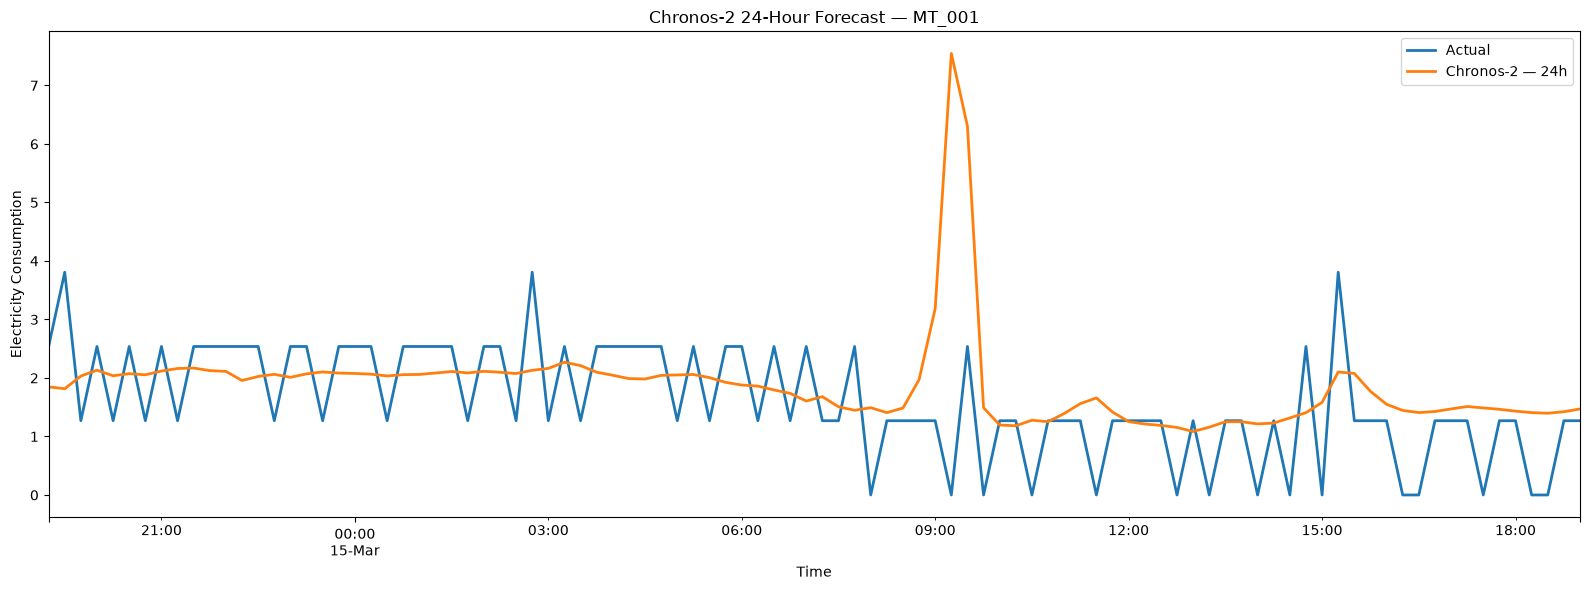

In [7]:
plt.figure(figsize=(16, 6))

actual_24h.plot(
    label="Actual"
)

forecast_24h.plot(
    label="Chronos-2 — 24h"
)

plt.title(
    f"Chronos-2 24-Hour Forecast — {SERIES_ID}"
)

plt.xlabel("Time")
plt.ylabel("Electricity Consumption")

plt.legend()
plt.tight_layout()
plt.show()

## 48 Hours

In [8]:
model_48h, actual_48h, forecast_48h = (
    run_chronos2_experiment(
        train=train,
        test=test,
        forecast_horizon=HORIZON_48H,
        input_chunk_length=INPUT_CHUNK_LENGTH,
    )
)

mae_48h = mae(
    actual_48h,
    forecast_48h
)

rmse_48h = rmse(
    actual_48h,
    forecast_48h
)

print(
    f"Chronos-2 48h MAE  : "
    f"{mae_48h:.6f}"
)

print(
    f"Chronos-2 48h RMSE : "
    f"{rmse_48h:.6f}"
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\chronos\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\chronos\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]

Chronos-2 48h MAE  : 0.795465
Chronos-2 48h RMSE : 1.208076


## 7 days

In [9]:
model_7d, actual_7d, forecast_7d = (
    run_chronos2_experiment(
        train=train,
        test=test,
        forecast_horizon=HORIZON_7D,
        input_chunk_length=INPUT_CHUNK_LENGTH,
    )
)

mae_7d = mae(
    actual_7d,
    forecast_7d
)

rmse_7d = rmse(
    actual_7d,
    forecast_7d
)

print(
    f"Chronos-2 7d MAE  : "
    f"{mae_7d:.6f}"
)

print(
    f"Chronos-2 7d RMSE : "
    f"{rmse_7d:.6f}"
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\chronos\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\chronos\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]

Chronos-2 7d MAE  : 0.964219
Chronos-2 7d RMSE : 1.799736


## Experiment comparision

In [10]:
chronos_results = pd.DataFrame({
    "Model": [
        "Chronos-2",
        "Chronos-2",
        "Chronos-2",
    ],
    "Horizon": [
        "24 hours",
        "48 hours",
        "7 days",
    ],
    "Steps": [
        HORIZON_24H,
        HORIZON_48H,
        HORIZON_7D,
    ],
    "MAE": [
        mae_24h,
        mae_48h,
        mae_7d,
    ],
    "RMSE": [
        rmse_24h,
        rmse_48h,
        rmse_7d,
    ],
})

display(
    chronos_results
)

,Model,Horizon,Steps,MAE,RMSE
0,Chronos-2,24 hours,96,0.763720,1.182067
1,Chronos-2,48 hours,192,0.795465,1.208076
2,Chronos-2,7 days,672,0.964219,1.799736


## Rolling Backtesting

In [11]:
BACKTEST_HORIZON = 96      # 24 hours
BACKTEST_STRIDE = 96       # every 24 hours
BACKTEST_START = 0.80

In [ ]:
backtest_forecasts = (
    run_chronos2_historical_forecasts(
        model=model_24h,
        series=series,
        forecast_horizon=BACKTEST_HORIZON,
        start=BACKTEST_START,
        stride=BACKTEST_STRIDE,
        retrain=True,
        last_points_only=True,
        verbose=True,
    )
)

print(
    "Backtesting completed."
)

print(
    backtest_forecasts
)

## Saving Metrics

In [11]:
from pathlib import Path

from src.evaluation import (
    evaluate_multiple_forecasts,
    save_metrics,
    save_forecast,
)

In [12]:
RESULTS_DIR = PROJECT_ROOT / "results"

In [13]:
from src.evaluation import save_actuals


chronos_experiments = [
    {
        "model_name": "Chronos-2",
        "actual": actual_24h,
        "forecast": forecast_24h,
        "series_id": SERIES_ID,
        "horizon": HORIZON_24H,
    },
    {
        "model_name": "Chronos-2",
        "actual": actual_48h,
        "forecast": forecast_48h,
        "series_id": SERIES_ID,
        "horizon": HORIZON_48H,
    },
    {
        "model_name": "Chronos-2",
        "actual": actual_7d,
        "forecast": forecast_7d,
        "series_id": SERIES_ID,
        "horizon": HORIZON_7D,
    },
]

chronos_metrics = evaluate_multiple_forecasts(
    chronos_experiments
)

# Read back whatever is already on disk from the baseline run,
# so this cell is safe to re-run without losing earlier rows
# or depending on baseline_metrics still being in memory.
metrics_path = RESULTS_DIR / "metrics.csv"

if metrics_path.exists():
    existing_metrics = pd.read_csv(metrics_path)
    all_metrics = pd.concat(
        [existing_metrics, chronos_metrics],
        ignore_index=True,
    )
else:
    all_metrics = chronos_metrics

save_metrics(
    all_metrics,
    metrics_path,
)

for experiment in chronos_experiments:

    save_forecast(
        forecast=experiment["forecast"],
        model_name=experiment["model_name"],
        series_id=experiment["series_id"],
        horizon=experiment["horizon"],
        path=RESULTS_DIR / "forecasts.csv",
    )
for experiment in chronos_experiments:  # or chronos_experiments in notebook 3
    save_actuals(
        actual=experiment["actual"],
        series_id=experiment["series_id"],
        horizon=experiment["horizon"],
        path=RESULTS_DIR / "actuals.csv",
    )

display(all_metrics)

,Model,Series_ID,Horizon,MAE,RMSE
0,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961
1,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641
2,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219
3,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251
4,Chronos-2,MT_001,96,0.763720,1.182067
5,Chronos-2,MT_001,192,0.795465,1.208076
6,Chronos-2,MT_001,672,0.964219,1.799736


In [15]:
import sys
from pathlib import Path

from darts import TimeSeries

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_dataset
from src.models import chronological_train_test_split
from src.evaluation import save_actuals

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "LD2011_2014.txt"
SERIES_ID = "MT_001"
RESULTS_DIR = PROJECT_ROOT / "results"

df = load_dataset(str(DATA_PATH))

series_df = (
    df[df["series_id"] == SERIES_ID]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

series = TimeSeries.from_dataframe(
    series_df,
    time_col="timestamp",
    value_cols="value",
    fill_missing_dates=False,
)

train, test = chronological_train_test_split(
    series,
    train_ratio=0.80,
)

for horizon in [96, 192, 672]:
    save_actuals(
        actual=test[:horizon],
        series_id=SERIES_ID,
        horizon=horizon,
        path=RESULTS_DIR / "actuals.csv",
    )

print("Saved actuals for horizons: 96, 192, 672")

Loading dataset: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt


c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\src\data.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Raw shape: (140256, 371)
Saved actuals for horizons: 96, 192, 672
